# **Five Assumptions of Linear Regression**

### **1. Linear Relationship**
The model assumes a **linear relationship between independent variables (X) and the dependent variable (Y)**.  
This means when X changes, Y changes in a straight-line pattern.

### **2. Multicollinearity**
Independent variables should **not be highly correlated with each other**.  
If predictors are strongly related, the model cannot clearly determine their individual effects.

### **3. Normal Residuals**
The **residuals (errors) should follow a normal distribution**.  
This helps make statistical tests and confidence intervals more reliable.

### **4. Homoscedasticity**
The **variance of residuals should remain constant** for all values of the predictors.  
In simple words, the spread of errors should be roughly the same across predictions.

### **5. No Autocorrelation of Errors**
The **residuals should be independent of each other**.  
An error in one observation should not influence the error in another observation, especially in time-based data.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Load dataset**

In [4]:
df = pd.read_csv('C:/Users/Awais/Desktop/100_days_of_ML/Day39_Assumptions_of_linear_Regression/data.csv')

In [5]:
df.head()

,Economic_Index,Market_Sentiment,Operational_Factor,Performance_Score
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [6]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

## **Train_test_split**

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## **1. Linear Relationship**

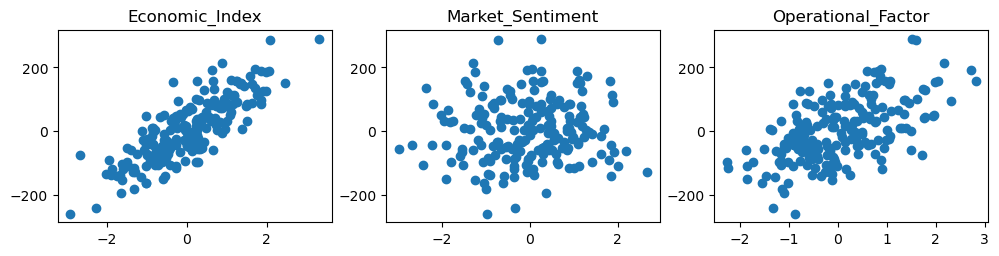

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['Economic_Index'], df['Performance_Score'])
ax1.set_title("Economic_Index")
ax2.scatter(df['Market_Sentiment'], df['Performance_Score'])
ax2.set_title("Market_Sentiment")
ax3.scatter(df['Operational_Factor'], df['Performance_Score'])
ax3.set_title("Operational_Factor")

plt.show()

- **The scatter plots show an approximately linear relationship between each feature and the target, suggesting linear regression is appropriate.**


## **2. Multicollinearity**

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [13]:
pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T

,Economic_Index,Market_Sentiment,Operational_Factor
vif,1.010326,1.009871,1.01395


#### 2nd way is Heatmap

<Axes: >

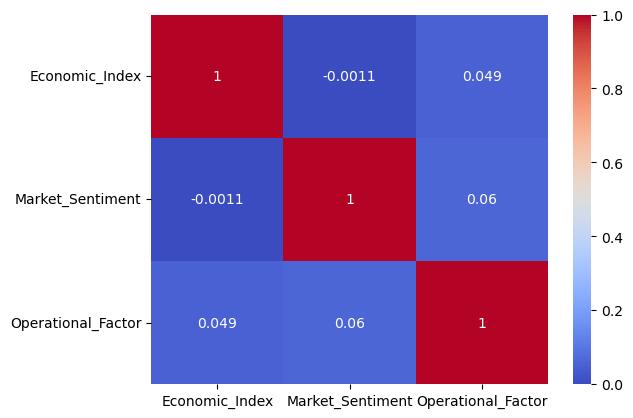

In [16]:
sns.heatmap(df.iloc[:,0:3].corr(),annot=True,cmap='coolwarm')

- **The VIF values are close to 1 and the correlation heatmap shows low correlation, indicating no multicollinearity among the features.**

## **3. Normality of Residual**

In [18]:
y_pred = model.predict(X_test) # residuals = actual - predicted
residual = y_test - y_pred

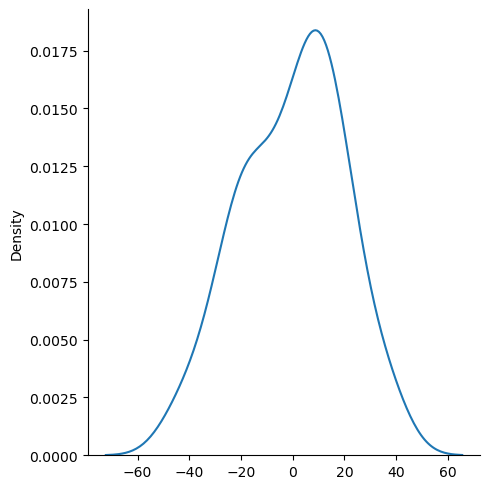

In [19]:
sns.displot(residual,kind='kde')

##  **QQ Plot**


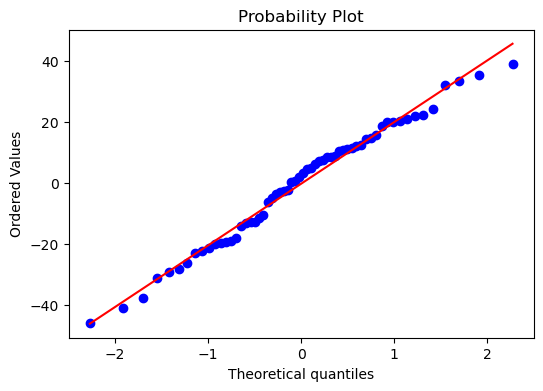

In [20]:

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

- **The residual distribution and QQ plot suggest that the residuals are approximately normally distributed.**

## **4. Homoscedasticity**

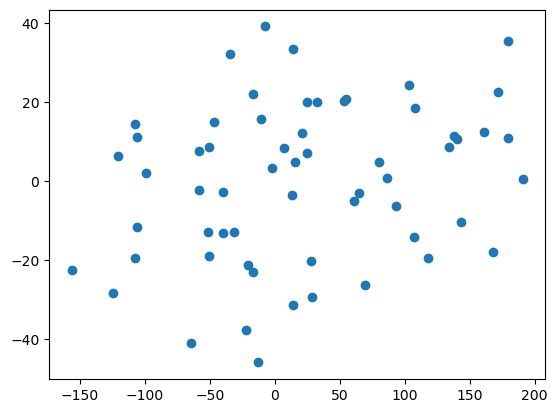

In [21]:
plt.scatter(y_pred,residual)

- **The residual vs predicted plot shows a fairly random spread, indicating constant variance of errors.**

## **5. Autocorrelation of Residuals**

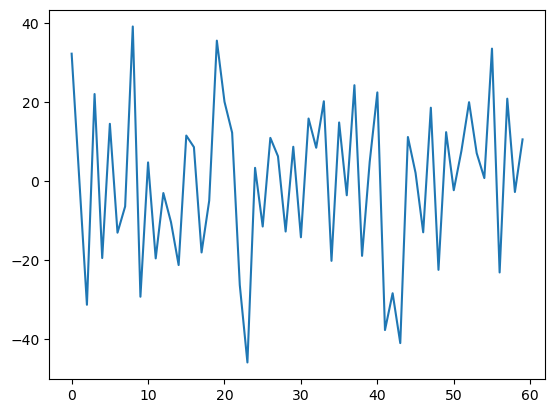

In [22]:
plt.plot(residual)

- **The residual plot does not show a clear pattern, suggesting that residuals are independent and not autocorrelated.**